In [49]:
import os

import polars as pl
import seaborn as sns
from matplotlib import pyplot as plt, rcParams
import synapseclient

rcParams["font.family"] = "Arial"
rcParams["font.size"] = 7

In [3]:
# Jupyter server should be running from src/python
# assumes auth_token.txt exists in src/python as described in setup instructions
AUTH_TOKEN = os.path.abspath("auth_token.txt")

# synapse IDs for the subset data
SUBSET_DATA_SYN_IDS = {
    "B_FLT3-ITDxNPM1-WT.arrow": "syn74776644",
    "B_FLT3-ITDxNPM1-WT.csv": "syn74776636",
    "B_FLT3-ITDxNPM1-WT_mut-cols.txt": "syn74776633",
    "B_FLT3-ITDxNPM1-WT_wt-cols.txt": "syn74776632",
    "B_NPM1-WT.arrow": "syn74776645",
    "B_NPM1-WT.csv": "syn74776649",
    "B_NPM1-WT_mut-cols.txt": "syn74776642",
    "B_NPM1-WT_wt-cols.txt": "syn74776643",
    "W_FLT3-ITDxNPM1-WT.arrow": "syn74776658",
    "W_FLT3-ITDxNPM1-WT.csv": "syn74776663",
    "W_FLT3-ITDxNPM1-WT_mut-cols.txt": "syn74776650",
    "W_FLT3-ITDxNPM1-WT_wt-cols.txt": "syn74776653",
    "W_NPM1-WT.arrow": "syn74776666",
    "W_NPM1-WT.csv": "syn74776667",
    "W_NPM1-WT_mut-cols.txt": "syn74776659",
    "W_NPM1-WT_wt-cols.txt": "syn74776660",
}

# directory for figures
FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "mutations",
    "_figures",
    "gene_sets"
)

In [4]:
# ensure diffex and figure directories exist
os.makedirs(FIGURE_DIR, exist_ok=True)

In [6]:
with open(AUTH_TOKEN, "r") as atf:
    SYN = synapseclient.login(authToken=atf.read())


UPGRADE AVAILABLE

A more recent version of the Synapse Client (4.12.0) is available. Your version (4.11.0) can be upgraded by typing:
   pip install --upgrade synapseclient

Python Synapse Client version 4.12.0 release notes

https://python-docs.synapse.org/news/


Welcome, dylan.ross!



In [70]:
# key: (subset_id, omics_data_type)
# value: (subset_df, wt_cols, mut_cols)
omics_subsets = {}

# load the relevant subsets of -omics data
for pop in "BW":
    for mut_comp in ["NPM1-WT", "FLT3-ITDxNPM1-WT"]:
        subset_id = f"{pop}_{mut_comp}"
        # load subset sample columns
        with open(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}_wt-cols.txt"]).path, "r") as wtf:
            wt_cols = wtf.read().split("\n")
        with open(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}_mut-cols.txt"]).path, "r") as mutf:
            mut_cols = mutf.read().split("\n")
        for omics_data_type in ["Transcriptomics", "Proteomics"]:
            # load subset df and select out the omics data type of interest
            omics_subset = (
                pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}.arrow"]).path)
                .filter(pl.col("Block") == omics_data_type)
                .drop("Block")
            )
            omics_subsets[subset_id, omics_data_type] = (omics_subset, wt_cols, mut_cols)

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/875095297.py:10: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}_wt-cols.txt"]).path, "r") as wtf:



[syn74776643:B_NPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/659/172720659/B_NPM1-WT_wt-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/875095297.py:12: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  with open(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}_mut-cols.txt"]).path, "r") as mutf:



[syn74776642:B_NPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/658/172720658/B_NPM1-WT_mut-cols.txt, skipping download.


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/875095297.py:17: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  pl.read_ipc(SYN.get(SUBSET_DATA_SYN_IDS[f"{subset_id}.arrow"]).path)



[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.
[syn74776645:B_NPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/663/172720663/B_NPM1-WT.arrow, skipping download.
[syn74776632:B_FLT3-ITDxNPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/643/172720643/B_FLT3-ITDxNPM1-WT_wt-cols.txt, skipping download.
[syn74776633:B_FLT3-ITDxNPM1-WT_mut-cols.txt]: Found existing file at /Users/dylan.ross/.synapseCache/644/172720644/B_FLT3-ITDxNPM1-WT_mut-cols.txt, skipping download.
[syn74776644:B_FLT3-ITDxNPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/662/172720662/B_FLT3-ITDxNPM1-WT.arrow, skipping download.
[syn74776644:B_FLT3-ITDxNPM1-WT.arrow]: Found existing file at /Users/dylan.ross/.synapseCache/662/172720662/B_FLT3-ITDxNPM1-WT.arrow, skipping download.
[syn74776660:W_NPM1-WT_wt-cols.txt]: Found existing file at /Users/dylan.ross/.synapse

In [64]:
def plot_gene_set(
    mut_name,
    b_subset_df, b_wt_cols, b_mut_cols,
    w_subset_df, w_wt_cols, w_mut_cols,
    gene_set
): 
    # select out and reformat a dataframe with only the genes from
    # the gene set for the black patients
    b_gene_set_df = (
        b_subset_df
        .unpivot(
            index="Feature",
            variable_name="Sample",
            value_name="Z-Score"
        )
        .with_columns(
            pl.col("Sample")
            .replace(
                {
                    k: "WT"
                    for k in b_wt_cols
                } | {
                    k: mut_name
                    for k in b_mut_cols
                }
            )
        )
        .filter(
            pl.col("Z-Score").is_not_null()
        )
        .filter(
            pl.col("Feature").is_in(gene_set)
        )
        .rename({"Feature": "Gene"})
    )
    b_genes_found = b_gene_set_df.unique("Gene")["Gene"].to_list()
    # plot the genes from the black patients
    print("black patients")
    fig, ax = plt.subplots(figsize=((len(b_genes_found) + 1) / 2, 2))
    sns.violinplot(
        data=b_gene_set_df,
        x="Gene",
        y="Z-Score",
        hue="Sample",
        linewidth=0.5,
        ax=ax,
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    sns.move_legend(ax, "upper right")
    plt.show()
    plt.close()
    # select out and reformat a dataframe with only the genes from
    # the gene set for the white patients
    w_gene_set_df = (
        w_subset_df
        .unpivot(
            index="Feature",
            variable_name="Sample",
            value_name="Z-Score"
        )
        .with_columns(
            pl.col("Sample")
            .replace(
                {
                    k: "WT"
                    for k in w_wt_cols
                } | {
                    k: mut_name
                    for k in w_mut_cols
                }
            )
        )
        .filter(
            pl.col("Z-Score").is_not_null()
        )
        .filter(
            pl.col("Feature").is_in(gene_set)
        )
        .rename({"Feature": "Gene"})
    )
    w_genes_found = w_gene_set_df.unique("Gene")["Gene"].to_list()
    # plot the genes from the black patients
    print("white patients")
    fig, ax = plt.subplots(figsize=((len(w_genes_found) + 1) / 2, 2))
    sns.violinplot(
        data=w_gene_set_df,
        x="Gene",
        y="Z-Score",
        hue="Sample",
        linewidth=0.5,
        ax=ax,
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    sns.move_legend(ax, "upper right")
    plt.show()
    plt.close()
    

---

In [65]:
# neutrophil granule proteins
neutrophil_granule = ["MPO", "PRTN3", "DEFA4", "BPI", "LTF", "CAMP", "SLPI", "CHI3L1", "PRG3", "S100A8", "LILRA3"]

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



black patients


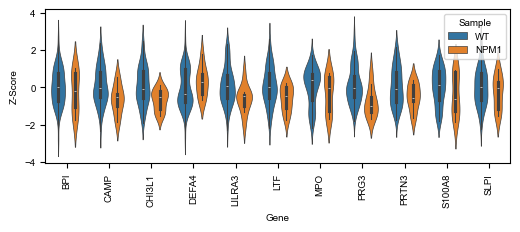

white patients


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



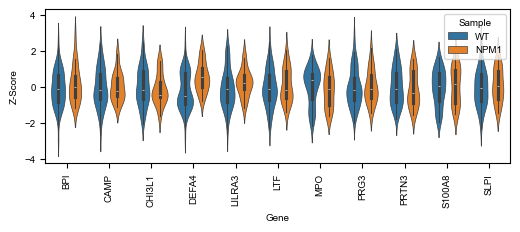

In [66]:
# plot the gene z-scores between wt and mutants from both populations
# mutation: NPM1
# omics type: Proteomics
plot_gene_set(
    "NPM1",
    *omics_subsets["B_NPM1-WT", "Proteomics"],
    *omics_subsets["W_NPM1-WT", "Proteomics"],
    neutrophil_granule
)

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



black patients


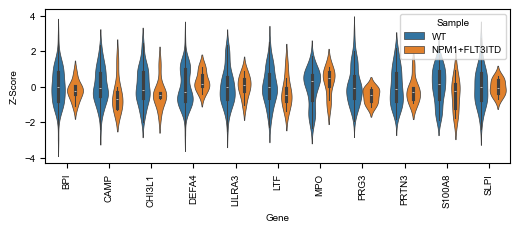

white patients


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



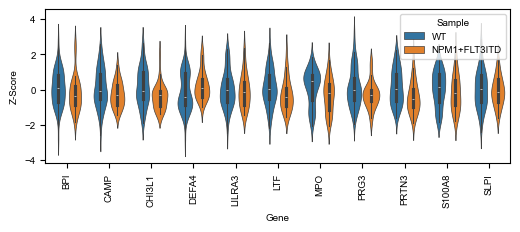

In [68]:
# plot the gene z-scores between wt and mutants from both populations
# mutation: NPM1+FLT3-ITD
# omics type: Proteomics
plot_gene_set(
    "NPM1+FLT3ITD",
    *omics_subsets["B_FLT3-ITDxNPM1-WT", "Proteomics"],
    *omics_subsets["W_FLT3-ITDxNPM1-WT", "Proteomics"],
    neutrophil_granule
)

---

In [87]:
inflammatory = ["ALOX5", "ALOX12", "PLA2G2A", "CXCL1", "ORM1", "FABP5", "HEBP2", "PADI2"]

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



black patients


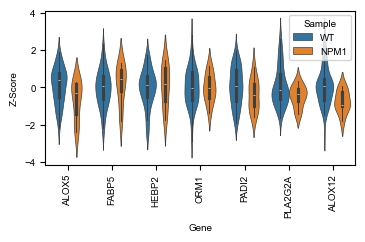

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



white patients


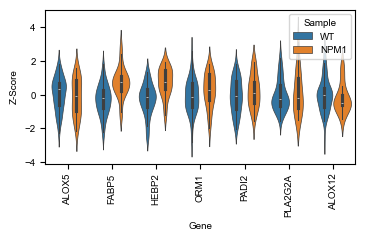

In [88]:
# plot the gene z-scores between wt and mutants from both populations
# mutation: NPM1
# omics type: Proteomics
plot_gene_set(
    "NPM1",
    *omics_subsets["B_NPM1-WT", "Proteomics"],
    *omics_subsets["W_NPM1-WT", "Proteomics"],
    inflammatory
)

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



black patients


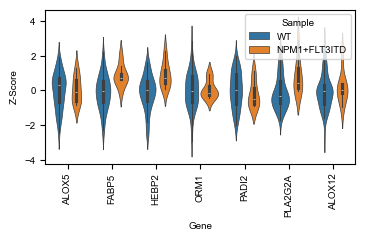

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



white patients


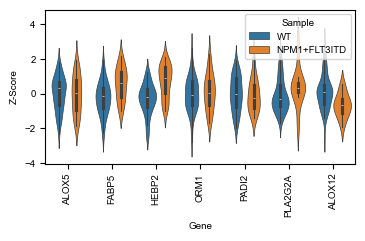

In [89]:
# plot the gene z-scores between wt and mutants from both populations
# mutation: NPM1+FLT3-ITD
# omics type: Proteomics
plot_gene_set(
    "NPM1+FLT3ITD",
    *omics_subsets["B_FLT3-ITDxNPM1-WT", "Proteomics"],
    *omics_subsets["W_FLT3-ITDxNPM1-WT", "Proteomics"],
    inflammatory
)

---

In [77]:
# vesicle trafficking, exocytosis: degranulation machinery
degranulation = ["RAB27A", "RAB31", "RAB3A", "RAB3D", "ATP6AP2", "ATP8B4", "ATG7"]

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



black patients


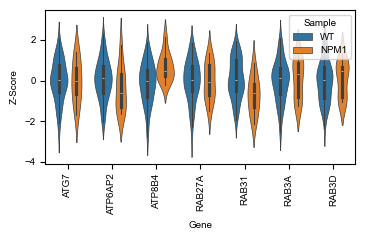

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



white patients


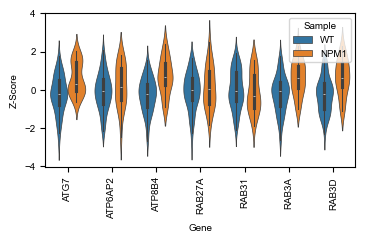

In [78]:
# plot the gene z-scores between wt and mutants from both populations
# mutation: NPM1
# omics type: Proteomics
plot_gene_set(
    "NPM1",
    *omics_subsets["B_NPM1-WT", "Proteomics"],
    *omics_subsets["W_NPM1-WT", "Proteomics"],
    degranulation
)

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



black patients


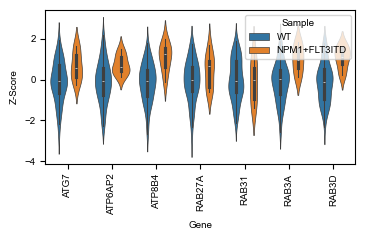

white patients


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



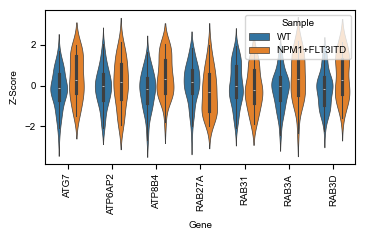

In [82]:
# plot the gene z-scores between wt and mutants from both populations
# mutation: NPM1+FLT3-ITD
# omics type: Proteomics
plot_gene_set(
    "NPM1+FLT3ITD",
    *omics_subsets["B_FLT3-ITDxNPM1-WT", "Proteomics"],
    *omics_subsets["W_FLT3-ITDxNPM1-WT", "Proteomics"],
    degranulation
)

---

In [79]:
# carbohydrate metabolism
carb_metab = ["GPI", "PGM1", "PGM2", "PYGB", "MGAM", "SLC2A3", "GALNS"]

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



black patients


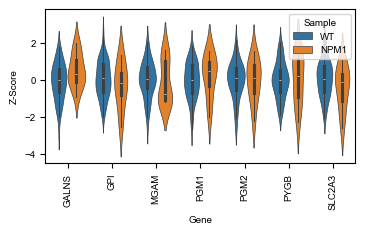

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



white patients


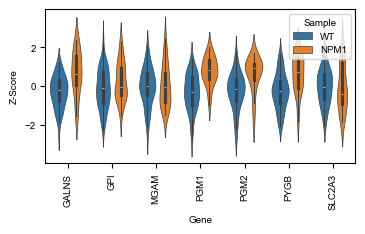

In [80]:
# plot the gene z-scores between wt and mutants from both populations
# mutation: NPM1
# omics type: Proteomics
plot_gene_set(
    "NPM1",
    *omics_subsets["B_NPM1-WT", "Proteomics"],
    *omics_subsets["W_NPM1-WT", "Proteomics"],
    carb_metab
)

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



black patients


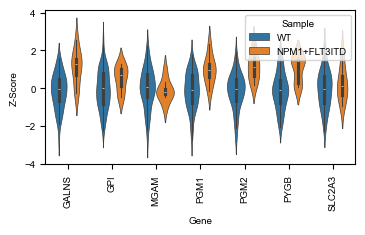

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



white patients


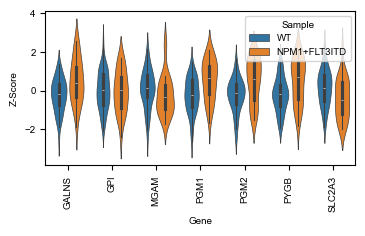

In [83]:
# plot the gene z-scores between wt and mutants from both populations
# mutation: NPM1+FLT3-ITD
# omics type: Proteomics
plot_gene_set(
    "NPM1+FLT3ITD",
    *omics_subsets["B_FLT3-ITDxNPM1-WT", "Proteomics"],
    *omics_subsets["W_FLT3-ITDxNPM1-WT", "Proteomics"],
    carb_metab
)

---

In [84]:
hsc_prog = ["CD34", "KIT", "CSF3R", "TFRC", "CD71"]

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



black patients


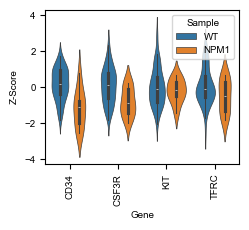

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



white patients


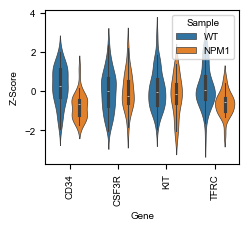

In [85]:
# plot the gene z-scores between wt and mutants from both populations
# mutation: NPM1
# omics type: Proteomics
plot_gene_set(
    "NPM1",
    *omics_subsets["B_NPM1-WT", "Proteomics"],
    *omics_subsets["W_NPM1-WT", "Proteomics"],
    hsc_prog
)

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



black patients


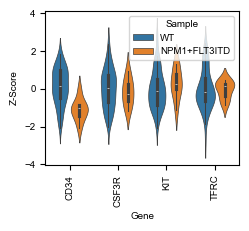

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



white patients


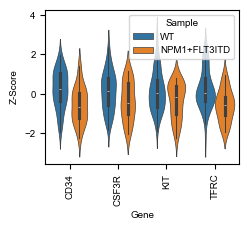

In [86]:
# plot the gene z-scores between wt and mutants from both populations
# mutation: NPM1+FLT3-ITD
# omics type: Proteomics
plot_gene_set(
    "NPM1+FLT3ITD",
    *omics_subsets["B_FLT3-ITDxNPM1-WT", "Proteomics"],
    *omics_subsets["W_FLT3-ITDxNPM1-WT", "Proteomics"],
    hsc_prog
)

---

In [90]:
innate_immune_cell_surface = ["TLR2", "CD14", "CLEC4D", "CLEC5A", "FCAR", "C5AR1", "CR1", "CD93", "CD55", "CD177", "CEACAM3", "CEACAM6", "CEACAM8", "PIGR"]

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



black patients


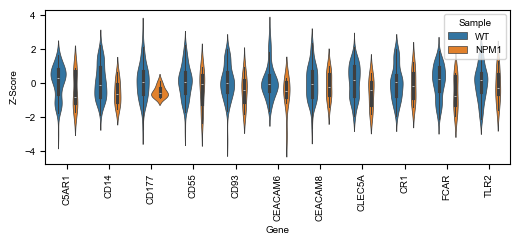

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



white patients


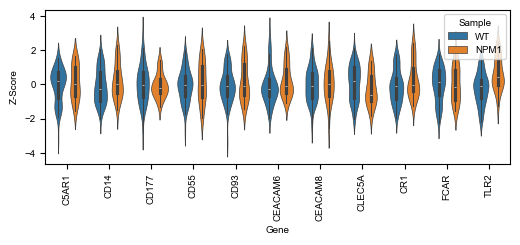

In [91]:
# plot the gene z-scores between wt and mutants from both populations
# mutation: NPM1
# omics type: Proteomics
plot_gene_set(
    "NPM1",
    *omics_subsets["B_NPM1-WT", "Proteomics"],
    *omics_subsets["W_NPM1-WT", "Proteomics"],
    innate_immune_cell_surface
)

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



black patients


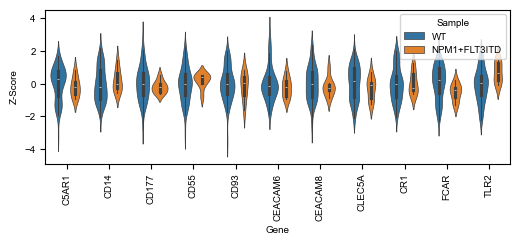

white patients


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



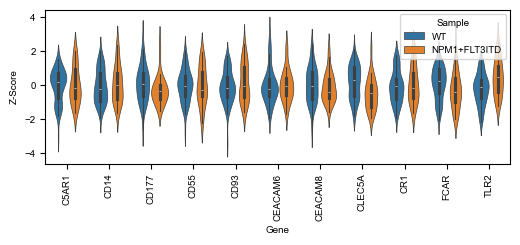

In [92]:
# plot the gene z-scores between wt and mutants from both populations
# mutation: NPM1+FLT3-ITD
# omics type: Proteomics
plot_gene_set(
    "NPM1+FLT3ITD",
    *omics_subsets["B_FLT3-ITDxNPM1-WT", "Proteomics"],
    *omics_subsets["W_FLT3-ITDxNPM1-WT", "Proteomics"],
    innate_immune_cell_surface
)

---

In [93]:
hox = [
    "HOXA2", "HOXA3", "HOXA4", "HOXA5", "HOXA6",
    "HOXA7", "HOXA8", "HOXA9", "HOXA10",
    "HOXB3", "HOXB4", "HOXB5", "HOXB6"
]

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



black patients


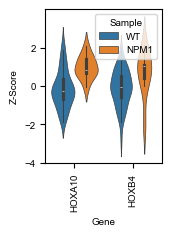

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



white patients


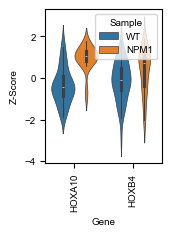

In [94]:
# plot the gene z-scores between wt and mutants from both populations
# mutation: NPM1
# omics type: Proteomics
plot_gene_set(
    "NPM1",
    *omics_subsets["B_NPM1-WT", "Proteomics"],
    *omics_subsets["W_NPM1-WT", "Proteomics"],
    hox
)

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



black patients


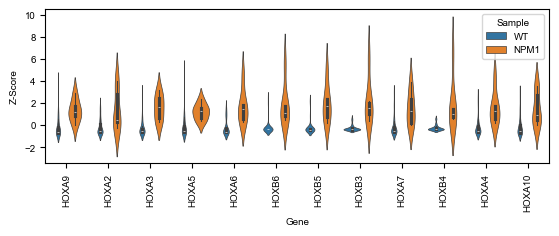

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



white patients


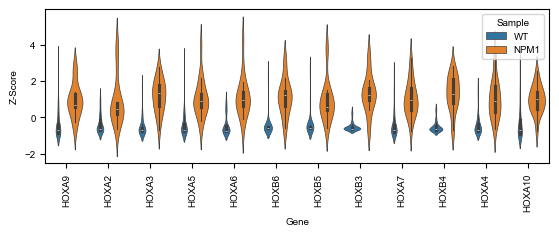

In [95]:
# plot the gene z-scores between wt and mutants from both populations
# mutation: NPM1
# omics type: Transcriptomics
plot_gene_set(
    "NPM1",
    *omics_subsets["B_NPM1-WT", "Transcriptomics"],
    *omics_subsets["W_NPM1-WT", "Transcriptomics"],
    hox
)

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



black patients


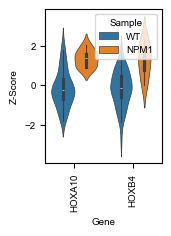

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



white patients


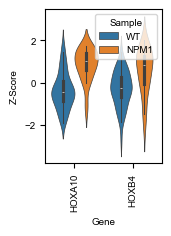

In [96]:
# plot the gene z-scores between wt and mutants from both populations
# mutation: NPM1+FLT3-ITD
# omics type: Proteomics
plot_gene_set(
    "NPM1",
    *omics_subsets["B_FLT3-ITDxNPM1-WT", "Proteomics"],
    *omics_subsets["W_FLT3-ITDxNPM1-WT", "Proteomics"],
    hox
)

[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



black patients


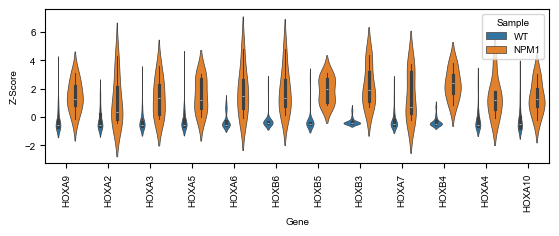

white patients


[WARNING] /var/folders/nb/ykfs58f552d0d0jd_2jnkx_80000gp/T/ipykernel_67536/1984612833.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)



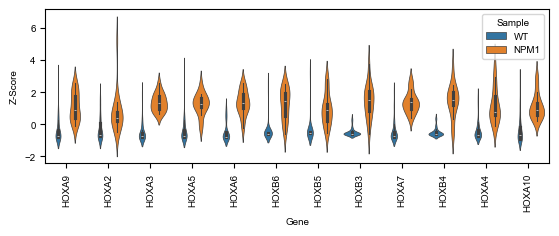

In [97]:
# plot the gene z-scores between wt and mutants from both populations
# mutation: NPM1+FLT3-ITD
# omics type: Transcriptomics
plot_gene_set(
    "NPM1",
    *omics_subsets["B_FLT3-ITDxNPM1-WT", "Transcriptomics"],
    *omics_subsets["W_FLT3-ITDxNPM1-WT", "Transcriptomics"],
    hox
)